# Netflix Data Analysis Project

---

## About This Project

In this project, I will analyze Netflix's content library using Python.
The dataset contains information about Movies and TV Shows available on Netflix.

### What I Will Do:
- Load and explore the dataset
- Clean the data (handle missing values, fix data types)
- Create visualizations to find interesting patterns
- Draw business insights from the analysis

### Tools Used:
- **Python** — programming language
- **Pandas** — for data manipulation
- **NumPy** — for numerical operations
- **Matplotlib** — for creating charts
- **Seaborn** — for statistical visualizations

---

## Step 1: Import Libraries

First, we import all the libraries we need for this project.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Hide unnecessary warnings
warnings.filterwarnings('ignore')

# Set a nice style for all plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---

## Step 2: Load the Dataset

Let's load the Netflix dataset and take a first look at it.

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv('../data/netflix_titles.csv')

# Check the size of the dataset
print('Number of rows    :', df.shape[0])
print('Number of columns :', df.shape[1])

Number of rows    : 8807
Number of columns : 12


In [3]:
# View the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# View the last 5 rows
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
# Get basic information about each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
# Get basic statistics for numerical columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# See all column names
print('Columns in the dataset:')
print(df.columns.tolist())

Columns in the dataset:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


---

## Step 3: Data Cleaning

Before analyzing the data, we need to clean it.
This includes handling missing values, removing duplicates,
and fixing data types.

### 3.1 Check for Missing Values

In [8]:
# Count missing values in each column
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [9]:
# Show missing values as percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print('Missing values percentage:')
print(missing_percent)

Missing values percentage:
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


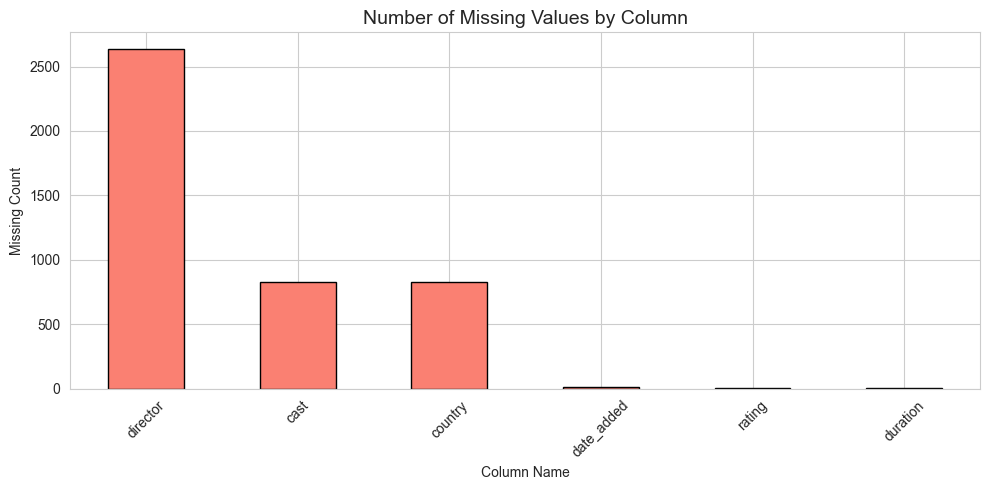

In [10]:
# Visualize missing values with a simple bar chart
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]  # only columns with missing values

plt.figure(figsize=(10, 5))
missing_data.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Number of Missing Values by Column', fontsize=14)
plt.xlabel('Column Name')
plt.ylabel('Missing Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Fill Missing Values

In [11]:
# Fill missing text columns with 'Not Available'
df['director'] = df['director'].fillna('Not Available')
df['cast']     = df['cast'].fillna('Not Available')
df['country']  = df['country'].fillna('Not Available')

# Fill missing date with forward fill
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = df['date_added'].ffill()

# Fill missing rating and duration with the most common value
df['rating']   = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# Check if missing values are handled
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


### 3.3 Remove Duplicate Rows

In [12]:
# Check for duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print('Shape after removing duplicates:', df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (8807, 12)


### 3.4 Fix Data Types & Create New Columns

In [13]:
# Convert 'date_added' column from text to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Extract year and month from date_added
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Extract only the number from duration (e.g. '90 min' -> 90)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Create separate DataFrames for Movies and TV Shows
df_movies  = df[df['type'] == 'Movie']
df_tvshows = df[df['type'] == 'TV Show']

print('New columns created: year_added, month_added, duration_int')
print('Total Movies  :', len(df_movies))
print('Total TV Shows:', len(df_tvshows))

New columns created: year_added, month_added, duration_int
Total Movies  : 6131
Total TV Shows: 2676


In [14]:
# Preview the cleaned dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1.0
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2.0


> **Insight:** After cleaning, we handled missing values in 6 columns, removed duplicates, converted the date column, and created 3 new helper columns that will be useful in our analysis.

---

---

## Step 4: Exploratory Data Analysis (EDA)

Now let's explore the data with visualizations to find interesting patterns.

### Chart 1: Movies vs TV Shows (Countplot)

How many Movies vs TV Shows are there on Netflix?

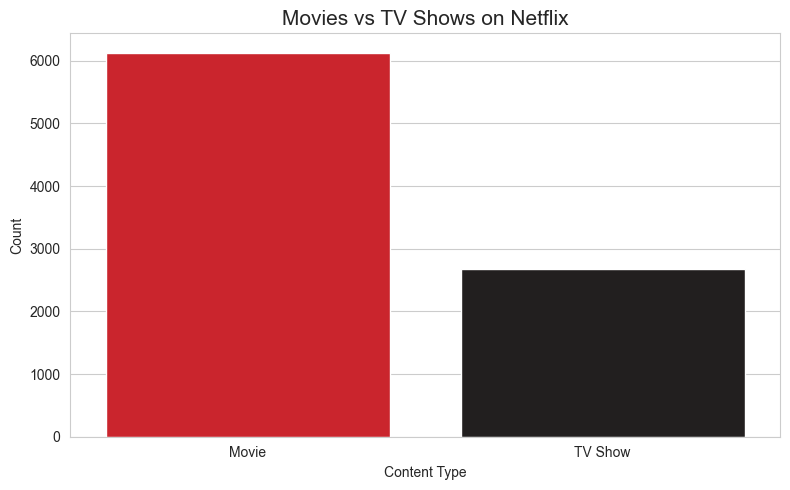

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])

plt.title('Movies vs TV Shows on Netflix', fontsize=15)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Print exact counts
print(df['type'].value_counts())

> **Insight:** Netflix has significantly more Movies than TV Shows.
Movies make up about 70% of the total content library.

### Chart 2: Release Year Distribution (Histogram)

In which years were the Netflix titles originally released?

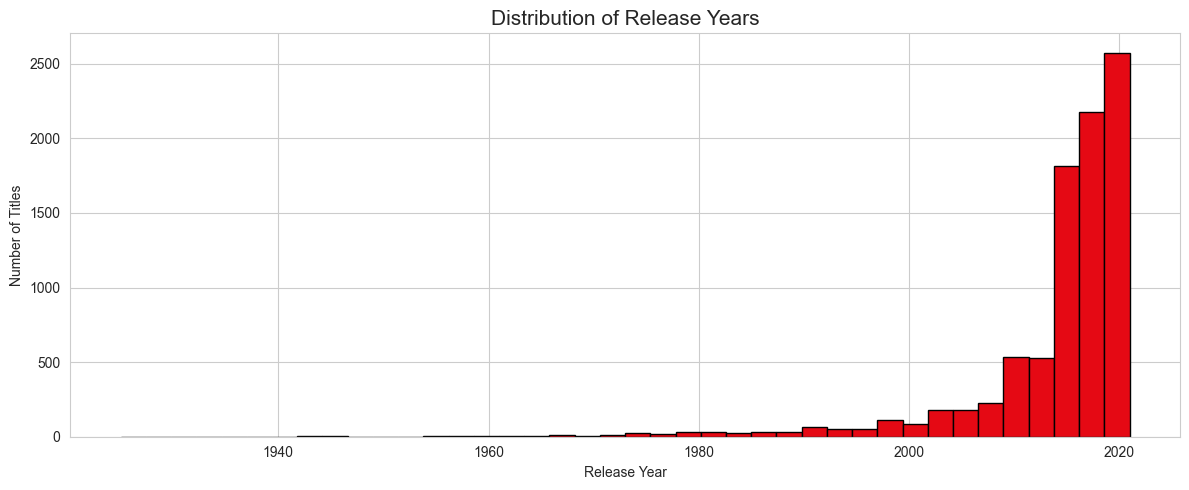

Oldest title released in: 1925
Newest title released in: 2021
Most common release year: 2018


In [16]:
plt.figure(figsize=(12, 5))

plt.hist(df['release_year'], bins=40, color='#E50914', edgecolor='black')

plt.title('Distribution of Release Years', fontsize=15)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

print('Oldest title released in:', int(df['release_year'].min()))
print('Newest title released in:', int(df['release_year'].max()))
print('Most common release year:', int(df['release_year'].mode()[0]))

> **Insight:** Most Netflix content was released after 2010.
The number of titles released each year has grown rapidly since 2015.

### Chart 3: Movie Duration (Boxplot)

How long are Netflix movies? Let's look at the spread of durations.

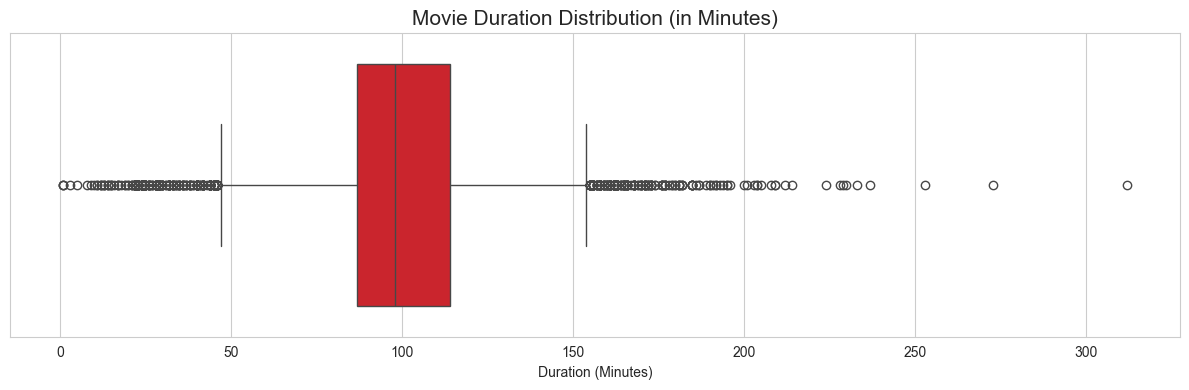

Average movie duration: 99.5 minutes
Shortest movie        : 1 minutes
Longest movie         : 312 minutes


In [17]:
plt.figure(figsize=(12, 4))

sns.boxplot(data=df_movies, x='duration_int', color='#E50914')

plt.title('Movie Duration Distribution (in Minutes)', fontsize=15)
plt.xlabel('Duration (Minutes)')
plt.tight_layout()
plt.show()

print('Average movie duration:', round(df_movies['duration_int'].mean(), 1), 'minutes')
print('Shortest movie        :', int(df_movies['duration_int'].min()), 'minutes')
print('Longest movie         :', int(df_movies['duration_int'].max()), 'minutes')

> **Insight:** Most Netflix movies are between 80 and 120 minutes long.
The average movie duration is around 99 minutes.

### Chart 4: Correlation Heatmap

Are there any relationships between the numerical columns?

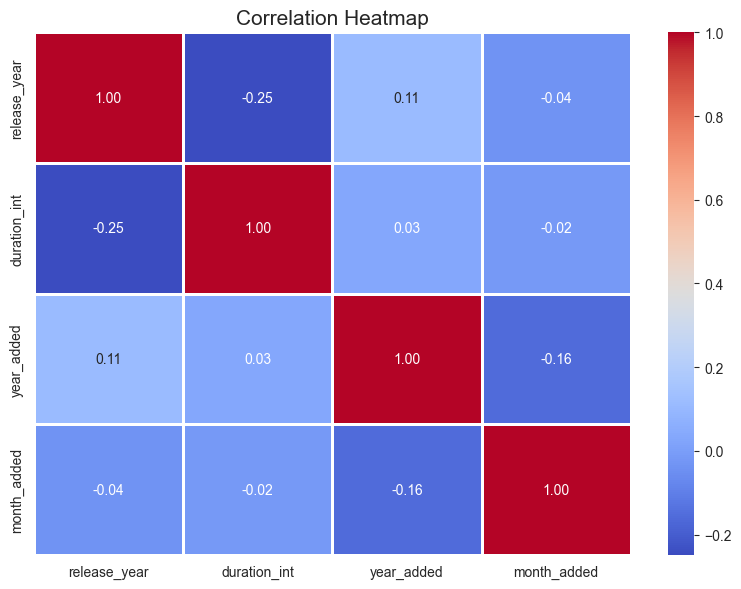

In [18]:
# Select only numerical columns
num_cols = ['release_year', 'duration_int', 'year_added', 'month_added']
corr_matrix = df[num_cols].dropna().corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)

plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

> **Insight:** Release year and year added have a moderate positive correlation,
meaning Netflix tends to add newer content more quickly to its platform.

### Chart 5: Top 10 Countries (Barplot)

Which countries produce the most Netflix content?

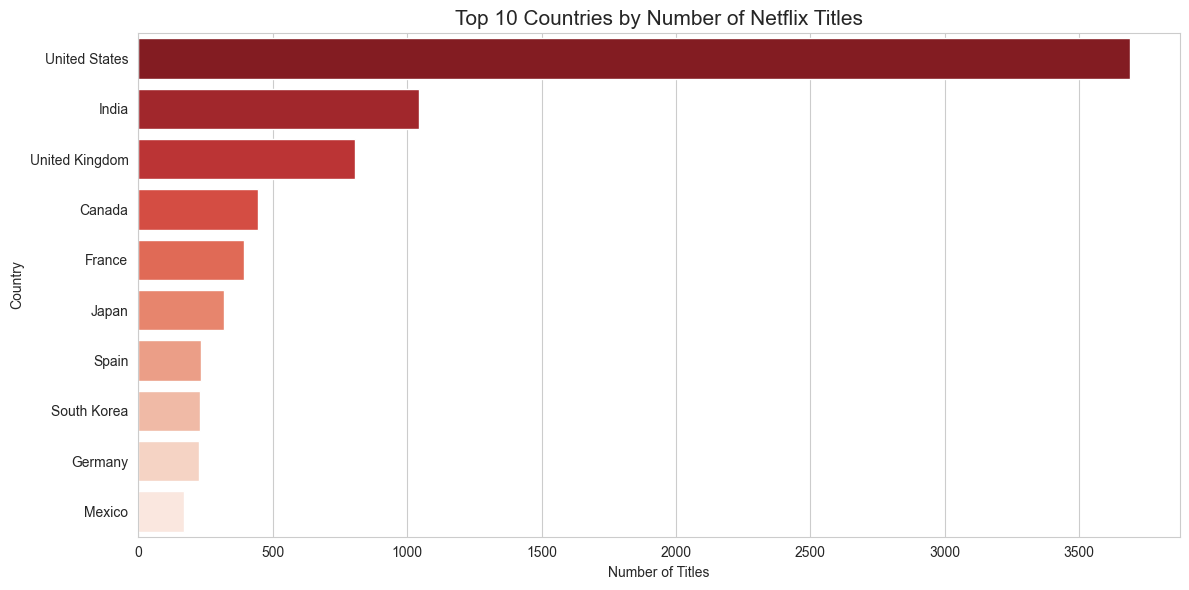

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [19]:
# Split countries (some titles have multiple countries listed)
country_list = df['country'].str.split(',').explode().str.strip()
country_list = country_list[country_list != 'Not Available']

# Get top 10 countries
top_10_countries = country_list.value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='Reds_r')

plt.title('Top 10 Countries by Number of Netflix Titles', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(top_10_countries)

> **Insight:** The United States produces the most Netflix content by far.
India is in second place, showing Netflix's strong focus on the Indian market.

### Chart 6: Release Year by Content Type (Violin Plot)

How do Movies and TV Shows differ in their release year distribution?

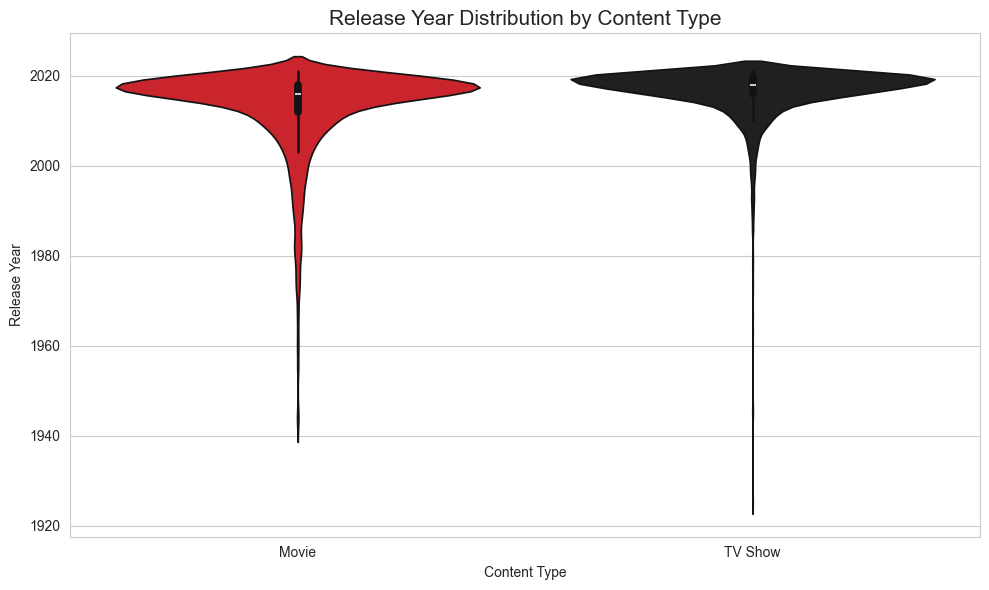

In [20]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x='type', y='release_year',
               palette=['#E50914', '#221F1F'], inner='box')

plt.title('Release Year Distribution by Content Type', fontsize=15)
plt.xlabel('Content Type')
plt.ylabel('Release Year')
plt.tight_layout()
plt.show()

> **Insight:** TV Shows on Netflix are mostly from recent years (2015–2021).
Movies have a wider spread, including older classic films.

### Chart 7: Pairplot of Numerical Features

Let's see all relationships between numerical features at once.

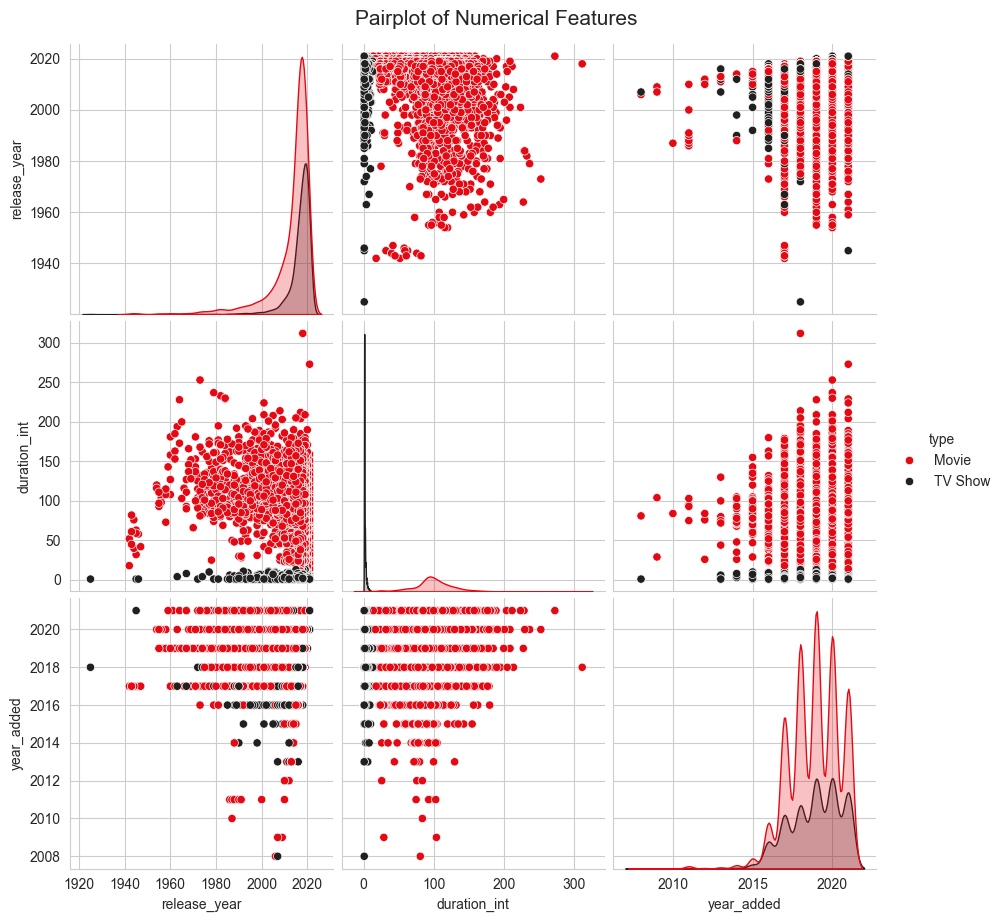

In [21]:
# Select columns for pairplot
pair_df = df[['release_year', 'duration_int', 'year_added', 'type']].dropna()

sns.pairplot(pair_df, hue='type', palette=['#E50914', '#221F1F'],
             diag_kind='kde', height=3)

plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=15)
plt.show()

> **Insight:** Movies and TV Shows clearly separate on the duration axis.
TV Shows have low duration values (1–15 seasons) while Movies range 60–200+ minutes.

### Chart 8: Movie Duration Density (KDE Plot)

A smooth curve showing the distribution of movie runtimes.

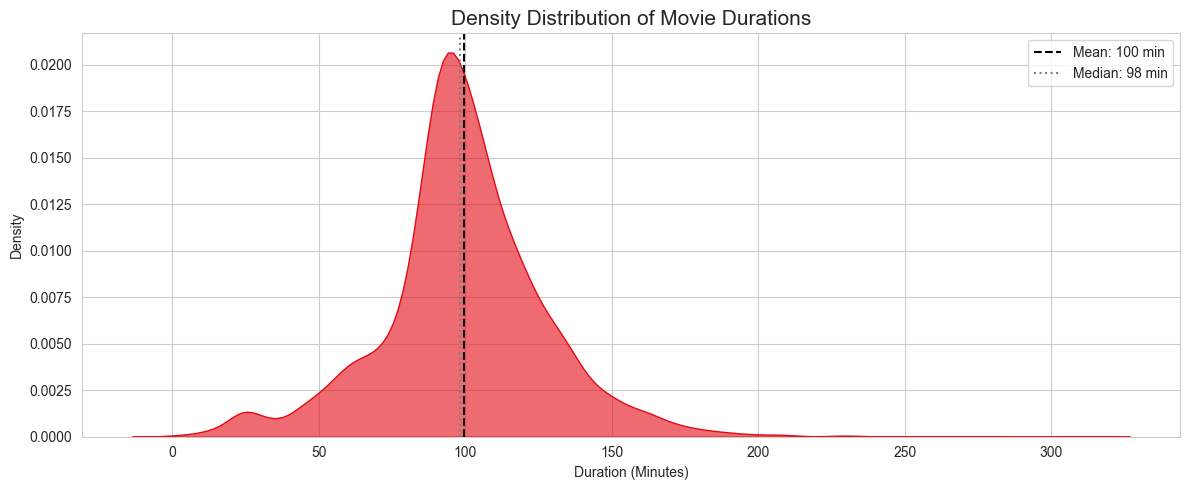

In [22]:
plt.figure(figsize=(12, 5))

sns.kdeplot(data=df_movies, x='duration_int', fill=True, color='#E50914', alpha=0.6)

# Add vertical lines for mean and median
mean_dur   = df_movies['duration_int'].mean()
median_dur = df_movies['duration_int'].median()

plt.axvline(mean_dur,   color='black',  linestyle='--', label=f'Mean: {mean_dur:.0f} min')
plt.axvline(median_dur, color='gray',   linestyle=':',  label=f'Median: {median_dur:.0f} min')

plt.title('Density Distribution of Movie Durations', fontsize=15)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

> **Insight:** The peak of the density curve is around 90–100 minutes.
This is the most common runtime for Netflix movies.

### Chart 9: Release Year vs Duration (Jointplot)

Does the release year of a movie affect its duration?

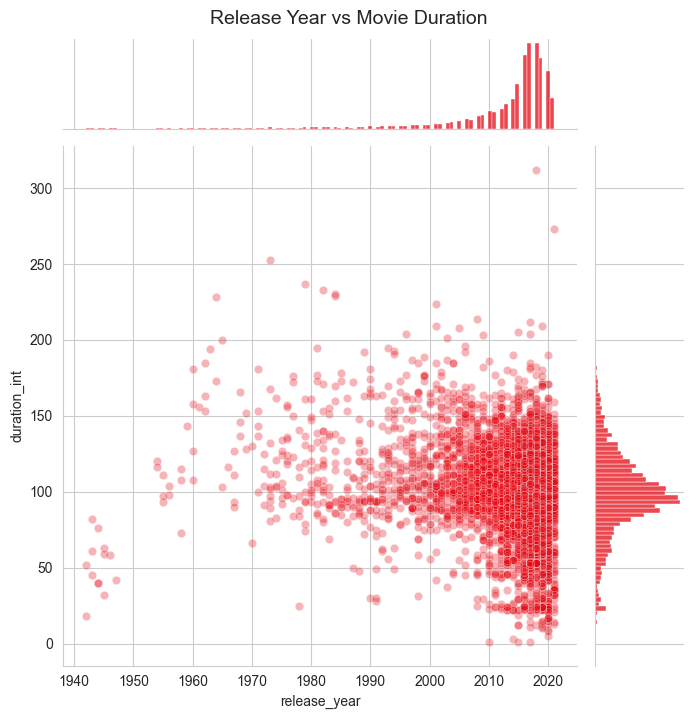

In [23]:
sns.jointplot(data=df_movies, x='release_year', y='duration_int',
              kind='scatter', color='#E50914', alpha=0.3, height=7)

plt.suptitle('Release Year vs Movie Duration', y=1.02, fontsize=14)
plt.show()

> **Insight:** Most movies are concentrated in the 2000–2021 range
with a duration between 80–120 minutes. Older movies tend to have more varied lengths.

### Chart 10: Movies vs TV Shows Percentage (Pie Chart)

What percentage of Netflix content is Movies vs TV Shows?

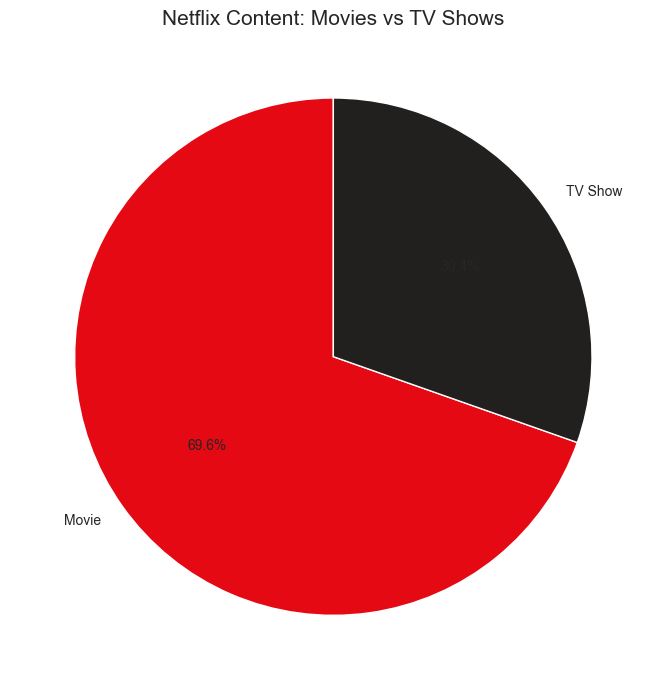

In [24]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(type_counts,
        labels=type_counts.index,
        autopct='%1.1f%%',
        colors=['#E50914', '#221F1F'],
        startangle=90)

plt.title('Netflix Content: Movies vs TV Shows', fontsize=15)
plt.tight_layout()
plt.show()

> **Insight:** About 70% of Netflix content is Movies and 30% is TV Shows.
Despite fewer TV Shows, they tend to keep viewers more engaged over time.

### Chart 11: Content Added Over the Years (Lineplot)

How has the number of titles added to Netflix grown each year?

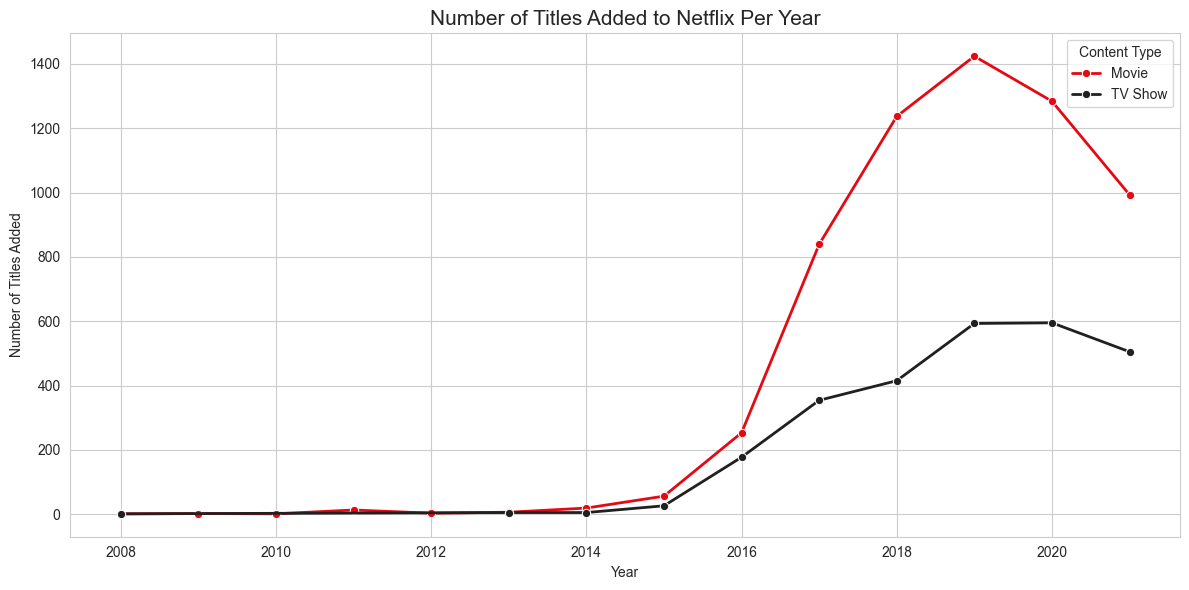

In [25]:
# Count titles added per year and type
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
yearly = yearly.dropna(subset=['year_added'])
yearly['year_added'] = yearly['year_added'].astype(int)

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly, x='year_added', y='count',
             hue='type', palette=['#E50914', '#221F1F'],
             marker='o', linewidth=2)

plt.title('Number of Titles Added to Netflix Per Year', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

> **Insight:** Netflix added content rapidly between 2015 and 2019.
There was a drop in 2020–2021, likely due to COVID-19 slowing down production.

### Chart 12: Rating Distribution by Content Type (Countplot)

What are the most common content ratings on Netflix for Movies and TV Shows?

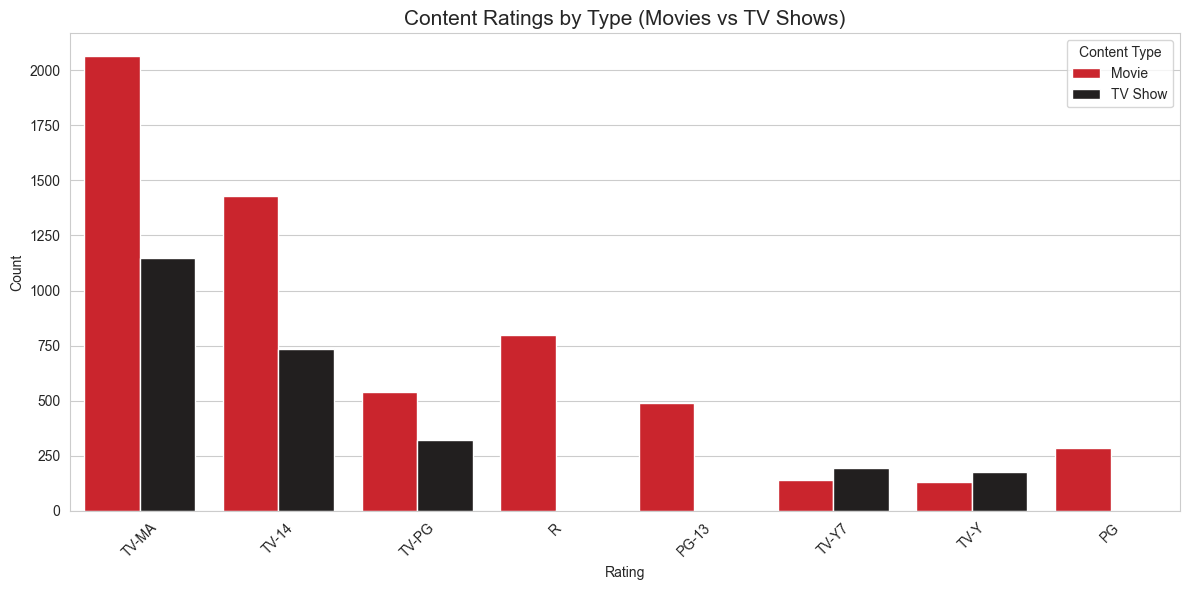

Most common ratings:
rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64


In [26]:
# Keep only the top 8 most common ratings
top_ratings = df['rating'].value_counts().head(8).index
df_filtered = df[df['rating'].isin(top_ratings)]

plt.figure(figsize=(12, 6))

sns.countplot(data=df_filtered, x='rating', hue='type',
              palette=['#E50914', '#221F1F'],
              order=top_ratings)

plt.title('Content Ratings by Type (Movies vs TV Shows)', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Content Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print value counts
print('Most common ratings:')
print(df['rating'].value_counts().head(8))

> **Insight:** TV-MA (Mature Audiences) is the most common rating on Netflix.
This shows Netflix mainly targets adult viewers.
There is very little content for children (rated G or TV-Y).

---

## Step 5: Key Business Insights

Here is a summary of the most important findings from the analysis:

| # | Insight |
|---|---|
| 1 | Netflix has ~70% Movies and ~30% TV Shows |
| 2 | Most content was released after 2010 |
| 3 | Average movie duration is around 99 minutes |
| 4 | The USA produces the most Netflix content; India is #2 |
| 5 | TV Shows are mostly recent (2015–2021); Movies include older titles |
| 6 | Netflix added content rapidly from 2015–2019; COVID slowed it in 2020–21 |
| 7 | TV-MA is the most common rating — Netflix targets adult audiences |
| 8 | Very little children's content (G, TV-Y ratings) on the platform |

---

## Conclusion

In this project, I:
- Loaded and explored a dataset of 8,800+ Netflix titles
- Cleaned missing values, removed duplicates, and fixed data types
- Created 12 different types of charts using Matplotlib and Seaborn
- Found key patterns in Netflix's content strategy

### Things I Can Do Next:
- Analyze the most popular genres on Netflix
- Build a simple movie recommendation system
- Create an interactive dashboard using Plotly
- Predict what type of content Netflix will add in the future

---

*Project by: [Your Name] | Tools: Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook*

---